In [3]:
import kagglehub
import os
import pandas as pd

# code to load data from explorer.ipynb
path = kagglehub.dataset_download("nudratabbas/global-company-layoffs-prediction-dataset")

train_df = pd.read_csv(os.path.join(path, "layoffs/train.csv"))
test_df = pd.read_csv(os.path.join(path, "layoffs/test.csv"))

Using Colab cache for faster access to the 'global-company-layoffs-prediction-dataset' dataset.


## Preprocessing pipeline

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

target_col = "layoff_happened"

X_train = train_df.drop(columns=[target_col]).copy()
y_train = train_df[target_col].copy()

X_test = test_df.drop(columns=[target_col]).copy()
y_test = test_df[target_col].copy()

# removing string company name as no predictive value
# based on eda potential set with only growth rate as predictor?
drop_cols = ["company"] 
X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")


# categorical encoding
categorical_cols = ["country", "industry"] 
for c in categorical_cols:
    if c in X_train.columns:
        X_train[c] = X_train[c].astype("category")
        X_test[c] = X_test[c].astype("category")


numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),],
    remainder="drop")

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_validate, StratifiedKFold

dummy_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=123))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

dummy_scores = cross_validate(
    dummy_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"])

print("Dummy CV accuracy:", dummy_scores["test_accuracy"].mean())
print("Dummy CV f1:", dummy_scores["test_f1"].mean())
print("Dummy CV roc_auc:", dummy_scores["test_roc_auc"].mean())

Dummy CV accuracy: 0.6838749999999999
Dummy CV f1: 0.0
Dummy CV roc_auc: 0.5


In [9]:
rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=10,
        random_state=123,
        class_weight="balanced",
        n_jobs=-1
    ))])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

rf_scores = cross_validate(
    rf_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False)

print("RF CV accuracy:", rf_scores["test_accuracy"].mean())
print("RF CV f1:", rf_scores["test_f1"].mean())
print("RF CV roc_auc:", rf_scores["test_roc_auc"].mean())

RF CV accuracy: 0.687125
RF CV f1: 0.33984148618451626
RF CV roc_auc: 0.6210326527585865


## Hyperparameter optimization — n_estimators

In [2]:
from plotnine import ggplot, aes, geom_line, geom_point, geom_ribbon, geom_hline, labs, theme_bw, annotate
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [ ]:
# first run was: [10, 25, 50, 100, 150, 200, 300, 500]
# best n was 150
# next run was [50, 75, 100, 125, 150, 175, 200]
# nice range of accuracy and std dev in 100---200
# still, we peak at 150 
n_estimator_values = [50, 75, 100, 125, 150, 175, 200]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

results = []
for n in n_estimator_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=123, class_weight="balanced", n_jobs=-1)
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", rf)])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    results.append({
        "n_estimators": n,
        "mean_accuracy": cv_results["test_score"].mean(),
        "std_accuracy": cv_results["test_score"].std(),
    })

results_df = pd.DataFrame(results)
best_n = results_df.loc[results_df["mean_accuracy"].idxmax(), "n_estimators"]
print(f"Best n_estimators: {best_n}")
results_df

Best n_estimators: 150


,n_estimators,mean_accuracy,std_accuracy
0,50,0.698125,0.003087
1,75,0.698500,0.004786
2,100,0.702375,0.004265
3,125,0.702125,0.006381
4,150,0.702625,0.004565
5,175,0.702250,0.004305
6,200,0.702500,0.003893


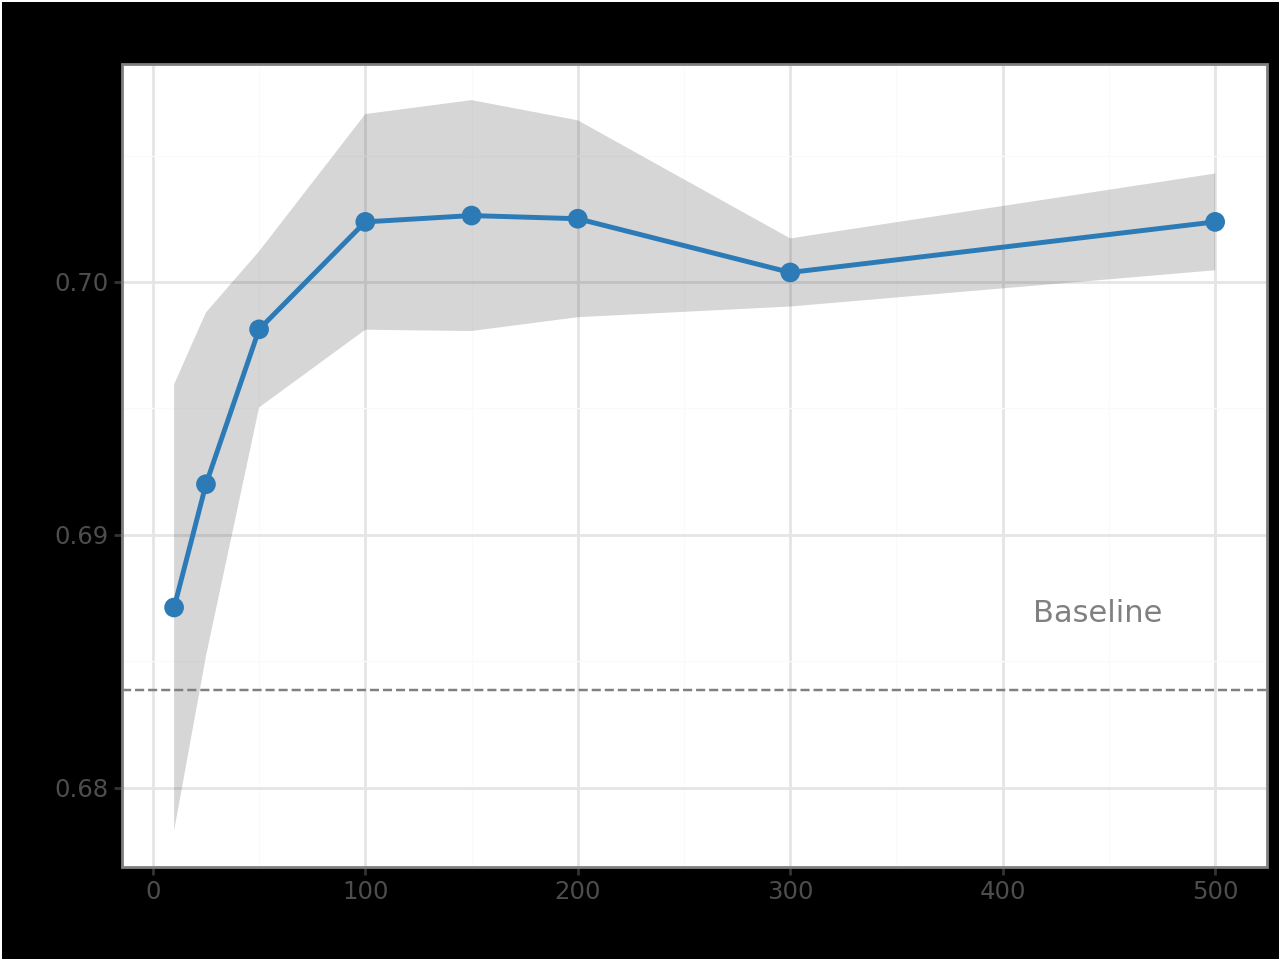

In [13]:
baseline_acc = dummy_scores["test_accuracy"].mean()  # DummyClassifier CV accuracy

(
    ggplot(results_df, aes(x="n_estimators", y="mean_accuracy"))
    + geom_ribbon(aes(ymin="mean_accuracy - std_accuracy", ymax="mean_accuracy + std_accuracy"), alpha=0.2)
    + geom_line(color="#2c7bb6", size=1)
    + geom_point(color="#2c7bb6", size=3)
    + geom_hline(yintercept=baseline_acc, linetype="dashed", color="gray")
    + annotate("text", x=max(n_estimator_values) * 0.95, y=baseline_acc + 0.003, label="Baseline", color="gray", ha="right")
    + labs(title="RF Accuracy vs n_estimators", x="n_estimators", y="Mean CV Accuracy (5-fold)")
    + theme_bw()
)